# TF-IDF + Logistic Regression

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### Загрузка данных

In [5]:
df = pd.read_csv("../data/ru-hard-detection-clean-v2.csv")

df["label"] = df["source"].map({
    "human": 0,
    "ai": 1
})
df['stratify_col'] = df['label'].astype(str) + "_" + df['dataset'].astype(str)
df['group_id'] = df['dataset'] + "_" + df['id'].astype(str)
df.iloc[478:482]

,id,text,model,source,dataset,noun_ratio,verb_ratio,adj_ratio,avg_word_len,pron_ratio,perf_verb_ratio,punct_ratio,avg_syntax_links,label,stratify_col,group_id
478,479,Творчество Льва Абрамовича Кассиля : нравствен...,deepseek-chat,ai,Corus Essays,0.280702,0.096491,0.142544,6.421875,0.026316,0.318182,0.157895,1.0,1,1_Corus Essays,Corus Essays_479
479,480,"предубеждениями, доказывая, что в борьбе за Ро...",gemini-2.0-flash,ai,Corus Essays,0.325260,0.089965,0.121107,6.122449,0.031142,0.423077,0.152249,1.0,1,1_Corus Essays,Corus Essays_480
480,1,Период с 1922 по 1939 год — время становления ...,NaN,human,Corus Essays,0.355408,0.055188,0.145695,6.391645,0.013245,0.800000,0.154525,1.0,0,0_Corus Essays,Corus Essays_1
481,2,"Время, в которое развернулась деятельность зна...",NaN,human,Corus Essays,0.320713,0.077951,0.129176,6.859375,0.026726,0.657143,0.144766,1.0,0,0_Corus Essays,Corus Essays_2


### Предобработка текста

In [6]:
import pymorphy3
import nltk
from nltk.tokenize import word_tokenize
# nltk.download("punkt")
morph = pymorphy3.MorphAnalyzer()


def clean_text(text: str):
    text = text.lower()
    tokens = word_tokenize(text)    
    clean_tokens = []
    for word in tokens:
        if word in '.,!?':
            clean_tokens.append(word)
        else:
            clean_tokens.append(morph.parse(word)[0].normal_form)
            
    return " ".join(clean_tokens)

In [7]:
df['cleaned_text'] = df['text'].apply(clean_text)

### Train / test split

In [8]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit

In [9]:
# X_train, X_test, y_train, y_test = train_test_split(
#     df["cleaned_text"],
#     df["label"],
#     test_size=0.2,
#     random_state=42,
#     stratify=df["stratify_col"]
# )

In [10]:
def split_data(X, y, group_by):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=group_by))

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    return X_train, X_test, y_train, y_test

In [11]:
ling_features = [
    "noun_ratio", "verb_ratio", "adj_ratio", "pron_ratio", 
    "perf_verb_ratio", "punct_ratio", "avg_syntax_links", "avg_word_len"
]

X = df[['cleaned_text'] + ling_features]
y = df['label']

X_train, X_test, y_train, y_test = split_data(X, y, df["group_id"])

### Сборка модели

#### Настройка пайплайна

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

In [16]:
preprocessor_std = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(ngram_range=(1, 3)), 'cleaned_text'),
        ('ling', StandardScaler(), ling_features)
    ]
)
preprocessor_minmax = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(ngram_range=(1, 3)), 'cleaned_text'),
        ('ling', MinMaxScaler(), ling_features) # Здесь замена!
    ]
)

experiments = {
    "LogisticRegression": {
        "model": Pipeline([
            ('preprocessor', preprocessor_std),
            ("clf", LogisticRegression(
                solver='liblinear',
                max_iter=1000,
                # n_jobs=-1,
                random_state=42
            ))
        ]),
        "params": {
            'preprocessor__tfidf__max_features': [10000, 30000, 50000],
            'clf__C': [0.1, 1, 10, 100],
            'clf__penalty': ['l1', 'l2']
        }
    },
    "NaiveBayes": {
        "model": Pipeline([
            ('preprocessor', preprocessor_minmax),
            ("clf", MultinomialNB())
        ]),
        "params": {
            "preprocessor__tfidf__max_features": [10000, 30000, 50000],
            "clf__alpha": [0.01, 0.1, 0.5, 1.0] # Главный параметр Баеса
        }
    },
    "RandomForest": {
        "model": Pipeline([
            ('preprocessor', preprocessor_std),
            ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        "params": {
            "preprocessor__tfidf__max_features": [10000, 20000],
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [None, 10, 20]
        }
    },
    # "CatBoost": {
    #     "model": Pipeline([
    #         ('preprocessor', preprocessor_std),
    #         ("clf", CatBoostClassifier(thread_count=-1, silent=True, task_type="GPU", devices='0'))
    #     ]),
    #     "params": {
    #         "preprocessor__tfidf__max_features": [10000, 30000],
    #         "clf__iterations": [200, 500],
    #         "clf__depth": [4, 6]
    #     }
    # }
}

#### Настраиваем сетку параметров

In [17]:
best_results = {}
for name, exp in experiments.items():
    print(f"\n=== Запуск GridSearchCV для модели: {name} ===")
    n_jobs = 1 if name == "CatBoost" else -1
    grid_search = GridSearchCV(
        exp["model"], 
        exp["params"], 
        cv=5, 
        scoring='f1', 
        n_jobs=n_jobs, 
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
 
    best_results[name] = {        
        "best_model": grid_search.best_estimator_,
        "best_score": grid_search.best_score_,
        "best_params": grid_search.best_params_
    }
    
    print(f"Результат {name}: F1 = {grid_search.best_score_:.4f}")
    print(f"Параметры: {grid_search.best_params_}")


=== Запуск GridSearchCV для модели: LogisticRegression ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits


c:\Users\danil\PycharmProjects\AiTextDetector\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Результат LogisticRegression: F1 = 0.9423
Параметры: {'clf__C': 100, 'clf__penalty': 'l2', 'preprocessor__tfidf__max_features': 10000}

=== Запуск GridSearchCV для модели: NaiveBayes ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Результат NaiveBayes: F1 = 0.9073
Параметры: {'clf__alpha': 0.01, 'preprocessor__tfidf__max_features': 50000}

=== Запуск GridSearchCV для модели: RandomForest ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Результат RandomForest: F1 = 0.9195
Параметры: {'clf__max_depth': None, 'clf__n_estimators': 100, 'preprocessor__tfidf__max_features': 20000}


#### Лучшая модель

In [18]:
winner_name = max(best_results, key=lambda x: best_results[x]["best_score"])
print(f"\n🏆 Победитель: {winner_name} с F1 = {best_results[winner_name]['best_score']:.4f}")


🏆 Победитель: LogisticRegression с F1 = 0.9423


### Метрики

In [19]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay)

In [20]:
model_metrics = {}
for name, res in best_results.items():
    model = res["best_model"]
    y_pred = model.predict(X_test)

    model_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
    }

### Матрица ошибок

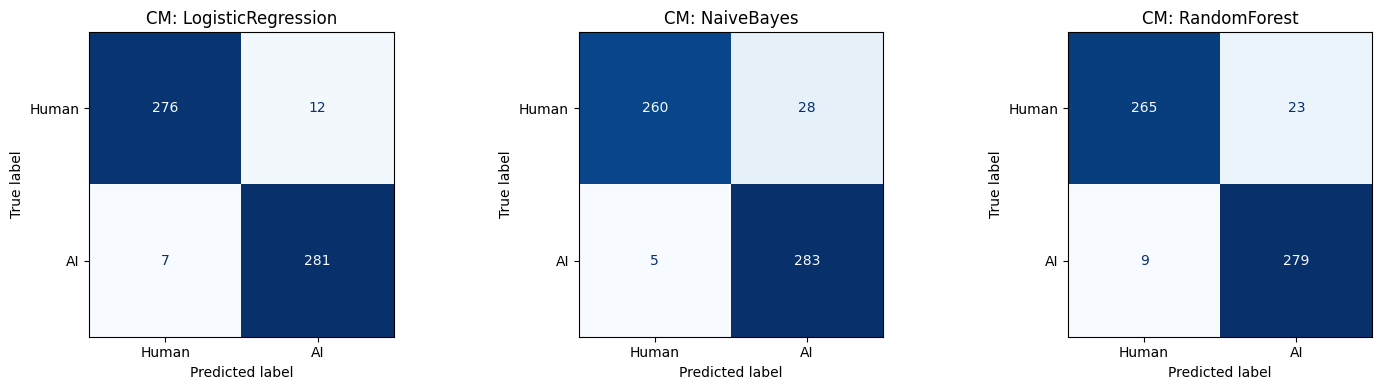

In [21]:
n_models = len(best_results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

if n_models == 1:
    axes = [axes]

for i, (name, res) in enumerate(best_results.items()):
    model = res["best_model"]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'AI'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"CM: {name}")

plt.tight_layout()
plt.show()

### Построение ROC-кривой

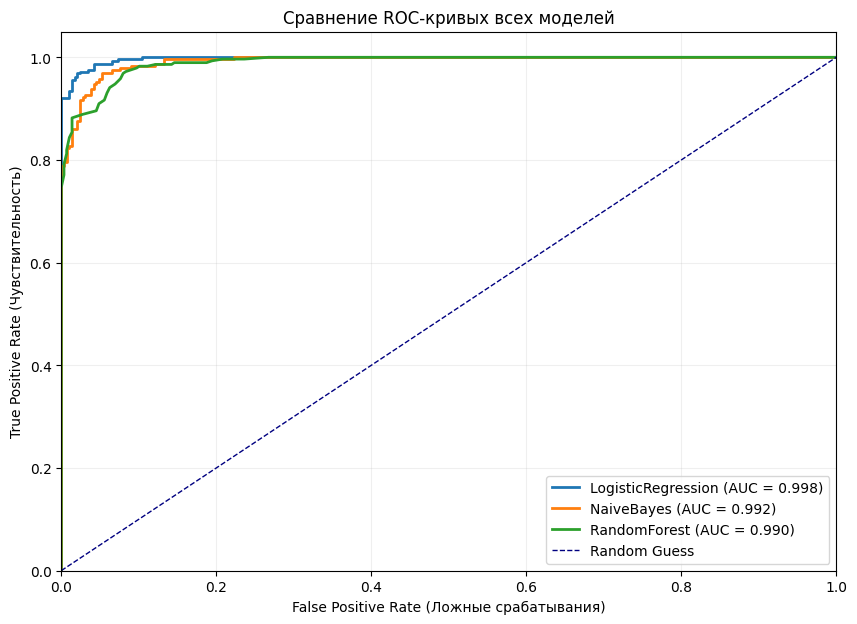

In [22]:
plt.figure(figsize=(10, 7))

for name, res in best_results.items():
    model = res["best_model"]
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
        
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Чувствительность)')
plt.title('Сравнение ROC-кривых всех моделей')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

#### Таблица итоговых метрик

In [23]:
metrics_df = pd.DataFrame(model_metrics).T
metrics_df = metrics_df.sort_values(by="F1", ascending=False).round(4)

display(metrics_df)

,Accuracy,Precision,Recall,F1
LogisticRegression,0.9670,0.9590,0.9757,0.9673
RandomForest,0.9444,0.9238,0.9688,0.9458
NaiveBayes,0.9427,0.9100,0.9826,0.9449


### Сохраняем лучшую модель для дальнейшего инференса

In [24]:
import os
import joblib
import re

os.makedirs('../models', exist_ok=True)

for name, res in best_results.items():
    safe_name = re.sub(r'[^a-zA-Z0-9_]+', '_', name)
    path = f'../models/v2/{safe_name}_model.pkl'
    
    joblib.dump(res["best_model"], path)

In [25]:
# Получаем веса из логистической регрессии
coefs = best_results['LogisticRegression']['best_model'].named_steps['clf'].coef_[0]

# Получаем имена признаков из TF-IDF
tfidf_features = best_results['LogisticRegression']['best_model'].named_steps['preprocessor'].transformers_[0][1].get_feature_names_out()

# Объединяем их с именами лингвистических колонок
all_feature_names = list(tfidf_features) + ling_features

# Создаем таблицу важности
feature_importance = pd.DataFrame({'feature': all_feature_names, 'importance': coefs})
feature_importance['abs_importance'] = feature_importance['importance'].abs()
feature_importance = feature_importance.sort_values(by='abs_importance', ascending=False)

print("🔝 ТОП-20 самых важных признаков для модели:")
print(feature_importance[['feature', 'importance']].head(20))

🔝 ТОП-20 самых важных признаков для модели:
           feature  importance
8302         стать    9.070866
9879          этот    8.708459
4494     не только    8.662551
6548           при   -8.406611
5018        однако    8.228257
8034      сообщать   -8.140839
8552     такой как    7.885935
3134      ключевой    7.799197
292          автор   -7.625825
5350    оставаться    7.471394
5793            по   -7.397078
1906           для    7.158714
4697            но    7.012749
9432       человек   -6.979042
6010  подчёркивать    6.825584
9739       эксперт    6.546423
3680         между    6.514703
1463           где    6.387327
5322      особенно    6.343938
2820      инцидент    6.215470


1. Маркеры ИИ (Положительные веса)
Это слова и обороты, которые модель считает признаком нейросети:

«стать», «оставаться»: ИИ обожает связочные глаголы. Вместо того чтобы сказать «он сделал», он напишет «это позволило ему стать...».

«этот», «такой как»: Типичные указательные конструкции и перечисления. ИИ часто структурирует текст через уточнения.

«не только», «однако»: Логические связки. Нейросети пишут очень логически выверенно, используя много союзов для «красивых» переходов.

«ключевой», «подчёркивать»: Это профессиональный жаргонизм ИИ. Он обожает выделять важность чего-либо этими словами.

«эксперт»: Популярное слово в сгенерированных статьях для придания «авторитетности».

2. Маркеры Человека (Отрицательные веса)
Слова, которые «успокаивают» модель и указывают на живого автора:

«сообщать», «инцидент»: Скорее всего, в твоем датасете человеческие тексты — это новости или репортажи. Модель запомнила, что реальные факты и события чаще описывают люди.

«автор», «человек»: Люди чаще пишут о людях напрямую.

«при», «по»: Короткие предлоги. Как ни странно, их обилие в определенных контекстах чаще встречается у людей.

3. Где наши лингвистические признаки?
В ТОП-20 их нет. Это нормально, потому что TF-IDF создает 30 000+ признаков, и отдельные слова-маркеры всегда будут иметь более резкий «вес», чем усредненные доли частей речи.

In [26]:
# Фильтруем только наши лингвистические колонки
ling_importance = feature_importance[feature_importance['feature'].isin(ling_features)]

print("📊 Вклад лингвистических признаков:")
print(ling_importance.sort_values(by='importance', ascending=False))

📊 Вклад лингвистических признаков:
                feature  importance  abs_importance
10001        verb_ratio    0.989162        0.989162
10000        noun_ratio    0.801889        0.801889
10007      avg_word_len    0.542468        0.542468
10002         adj_ratio    0.230845        0.230845
10005       punct_ratio    0.140216        0.140216
10006  avg_syntax_links    0.000000        0.000000
10004   perf_verb_ratio   -0.451860        0.451860
10003        pron_ratio   -0.728474        0.728474


1. Стилистический портрет ИИ (Положительный вес)
Модель считает текст нейросетевым, если в нем растут эти показатели:

verb_ratio (0.98) и noun_ratio (0.80): Это забавно! Твой классификатор заметил, что ИИ строит очень плотные предложения, перегруженные и действиями, и объектами. Это тот самый «информационный стиль», где каждое слово должно нести смысл.

avg_word_len (0.54): Подтвердилось! ИИ использует слова, которые в среднем длиннее. Он не скажет «есть», он скажет «употреблять» или «функционировать».

2. Стилистический портрет Человека (Отрицательный вес)
Эти признаки «успокаивают» детектор и склоняют его к версии, что автор — человек:

pron_ratio (-0.72): Как мы и гадали! Местоимения («я», «ты», «мы», «он») — главный враг нейросетей. ИИ старается быть отстраненным, а человек постоянно ссылается на себя или собеседника.

perf_verb_ratio (-0.45): А вот тут сюрприз. Отрицательный вес означает, что совершенный вид глагола («сделал», «пришел») чаще встречается у твоих людей. Это логично, если люди пишут новости (событие произошло), а ИИ генерирует рассуждения в неопределенной форме.

3. Странность с синтаксисом
avg_syntax_links (0.000): Модель вообще проигнорировала этот признак.

Почему? Скорее всего, среднее количество связей в чанках оказалось слишком похожим. Или, что более вероятно, StandardScaler превратил их в такие значения, которые LogReg посчитала менее полезными, чем конкретное слово «стать».